In [4]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 1. Initialize TensorFlow Mirrored Strategy for Dual GPUs
gpus = tf.config.list_physical_devices('GPU')
if len(gpus) >= 2:
    # Explicitly instruct TensorFlow to mirror variables across GPU:0 and GPU:1
    strategy = tf.distribute.MirroredStrategy(devices=["GPU:0", "GPU:1"])
    print(f"🎉 Success! Distributing workloads across {strategy.num_replicas_in_sync} Tesla T4 GPUs.")
elif len(gpus) == 1:
    strategy = tf.distribute.get_strategy()
    print("⚠️ Only 1 GPU found. Running on single accelerator mode.")
else:
    strategy = tf.distribute.get_strategy()
    print("⚠️ No GPUs detected. Defaulting to CPU execution loop.")

# 2. Hardcoded Competition Dataset Path Verified via Your Environment
path = "/kaggle/input/competitions/pokemon-tcg-ai-battle-challenge-strategy"
print("Data directory correctly routed to:", path)

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
🎉 Success! Distributing workloads across 2 Tesla T4 GPUs.
Data directory correctly routed to: /kaggle/input/competitions/pokemon-tcg-ai-battle-challenge-strategy


In [5]:
def preprocess_pokemon_data(base_path):
    csv_file = os.path.join(base_path, "EN_Card_Data.csv")
    df = pd.read_csv(csv_file)
    
    # 1. Clean Numerical Columns (Handling blanks for non-creature cards)
    df['HP'] = df['HP'].fillna(0).astype(np.float32)
    
    # Text damage fields often contain signs like '30+' or '120x'. We strip non-numeric characters.
    df['Damage'] = df['Damage'].astype(str).str.extract(r'(\d+)').fillna(0).astype(np.float32)
    
    # 2. Categorical Variable Encodings
    categorical_cols = [
        'Stage (Pokémon)/Type (Energy and Trainer)', 
        'Category', 
        'Type', 
        'Weakness'
    ]
    encoders = {}
    
    for col in categorical_cols:
        df[col] = df[col].fillna('None/Missing').astype(str)
        le = LabelEncoder()
        df[f'{col}_encoded'] = le.fit_transform(df[col])
        encoders[col] = le
        
    return df, encoders

# Execute clean data parsing
df_cards, encoders = preprocess_pokemon_data(path)
print(f"Dataset active: {df_cards.shape[0]} unique structural card records indexed.")

# Generate synthetic combinations to compute synergy pairs
num_cards = len(df_cards)
pair_a = np.random.randint(0, num_cards, size=100000)
pair_b = np.random.randint(0, num_cards, size=100000)

# Label = 1 if the cards share an elemental Type (high default archetype alignment)
targets = (df_cards['Type_encoded'].values[pair_a] == df_cards['Type_encoded'].values[pair_b]).astype(np.float32)

# Build feature tensors
feature_names = ['HP', 'Damage', 'Category_encoded', 'Stage (Pokémon)/Type (Energy and Trainer)_encoded']
X_a = df_cards[feature_names].values[pair_a]
X_b = df_cards[feature_names].values[pair_b]

X_a_train, X_a_val, X_b_train, X_b_val, y_train, y_val = train_test_split(
    X_a, X_b, targets, test_size=0.15, random_state=42
)

# 3. Optimized T4 Batch Size Placement
# Each Tesla T4 gets 256 samples, aggregating to an optimal global footprint of 512.
BATCH_SIZE_PER_REPLICA = 256
GLOBAL_BATCH_SIZE = BATCH_SIZE_PER_REPLICA * strategy.num_replicas_in_sync

train_loader = tf.data.Dataset.from_tensor_slices(((X_a_train, X_b_train), y_train)).shuffle(20000).batch(GLOBAL_BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_loader = tf.data.Dataset.from_tensor_slices(((X_a_val, X_b_val), y_val)).batch(GLOBAL_BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

Dataset active: 2022 unique structural card records indexed.


In [7]:
def build_gpu_siamese_network(input_shape):
    # Core representation network block
    card_input = tf.keras.Input(shape=(input_shape,), name="individual_card_features")
    dense_1 = tf.keras.layers.Dense(512, activation='swish')(card_input)
    norm_1 = tf.keras.layers.BatchNormalization()(dense_1)
    drop_1 = tf.keras.layers.Dropout(0.2)(norm_1)
    
    dense_2 = tf.keras.layers.Dense(256, activation='swish')(drop_1)
    embedding_vector = tf.keras.layers.Dense(128, activation='linear', name="dense_latent_space")(dense_2)
    
    base_encoder = tf.keras.Model(card_input, embedding_vector, name="Base_Card_Encoder")
    
    # Dual processing paths
    input_a = tf.keras.Input(shape=(input_shape,), name="card_arm_a")
    input_b = tf.keras.Input(shape=(input_shape,), name="card_arm_b")
    
    embedded_a = base_encoder(input_a)
    embedded_b = base_encoder(input_b)
    
    # FIX: Symmetrically subtract the vectors, then apply an absolute value transformation via Lambda
    diff = tf.keras.layers.Subtract()([embedded_a, embedded_b])
    interaction = tf.keras.layers.Lambda(lambda x: tf.abs(x), name="absolute_difference")(diff)
    
    final_dense = tf.keras.layers.Dense(64, activation='swish')(interaction)
    prediction = tf.keras.layers.Dense(1, activation='sigmoid', name="synergy_index")(final_dense)
    
    full_network = tf.keras.Model(inputs=[input_a, input_b], outputs=prediction)
    return full_network, base_encoder

# Compile within Distributed Context Symmetrically
with strategy.scope():
    feature_dim = X_a_train.shape[1]
    gpu_model, encoder_engine = build_gpu_siamese_network(feature_dim)
    
    gpu_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss=tf.keras.losses.BinaryCrossentropy(),
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )

gpu_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ card_arm_a          │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ card_arm_b          │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Base_Card_Encoder   │ (None, 128)       │    168,832 │ card_arm_a[0][0], │
│ (Functional)        │                   │            │ card_arm_b[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ subtract (Subtract) │ (None, 128)       │          0 │ Base_Card_Encode… │
│                     │                   │            │ Base_Card_Encode… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ absolute_difference │ (None, 128)       │          0 │ subtract[0][0]    │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │      8,256 │ absolute_differe… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ synergy_index       │ (None, 1)         │         65 │ dense_4[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 177,153 (692.00 KB)

 Trainable params: 176,129 (688.00 KB)

 Non-trainable params: 1,024 (4.00 KB)

In [9]:
# 1. Define the Early Stopping Configuration
early_stopping_callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',             # Watch validation loss for signs of overfitting/plateau
    patience=20,                    # Stop training if val_loss doesn't improve for 30 consecutive epochs
    restore_best_weights=True,      # Automatically roll back to the absolute best weights found
    verbose=1                       # Print a clean confirmation message when triggered
)

# 2. Scale Up the Optimization Runway
EPOCHS = 100

print("🛰️ Commencing Synchronous Multi-GPU Training Operations...")
print(f"Running up to {EPOCHS} epochs with a 30-epoch early stopping patience buffer.")

gpu_history = gpu_model.fit(
    train_loader,
    validation_data=val_loader,
    epochs=EPOCHS,
    callbacks=[early_stopping_callback],  # Pass our stopping condition array here
    verbose=1
)

print("\n🧬 Extracting mathematical deck strategy embeddings using the SELECTED BEST weights...")
raw_features = df_cards[feature_names].values
card_embeddings = encoder_engine.predict(raw_features)

# 3. Save peak performance dimensional arrays back to file
for dimension in range(128):
    df_cards[f'strat_vector_{dimension}'] = card_embeddings[:, dimension]

df_cards.to_csv("pokemon_gpu_strategy_embeddings.csv", index=False)
print("💾 File saved as 'pokemon_gpu_strategy_embeddings.csv'!")
print("Your card embeddings have been extracted from the absolute best epoch during training.")

🛰️ Commencing Synchronous Multi-GPU Training Operations...
Running up to 100 epochs with a 30-epoch early stopping patience buffer.
Epoch 1/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9102 - auc: 0.6573 - loss: 0.2836 - val_accuracy: 0.9083 - val_auc: 0.6484 - val_loss: 0.2857
Epoch 2/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9102 - auc: 0.6580 - loss: 0.2836 - val_accuracy: 0.9089 - val_auc: 0.6512 - val_loss: 0.2837
Epoch 3/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9101 - auc: 0.6604 - loss: 0.2833 - val_accuracy: 0.9090 - val_auc: 0.6479 - val_loss: 0.2856
Epoch 4/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9096 - auc: 0.6562 - loss: 0.2854 - val_accuracy: 0.9082 - val_auc: 0.6524 - val_loss: 0.2976
Epoch 5/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9102 - auc: 0.6589 - loss: 0.2834 - val_accuracy: 0.9088 - val_auc: 0.6444 - val_loss: 0.2926
Epoch 6/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - ac

In [10]:
import os

# Create a clean directory for structural model versions
model_export_dir = "./pokemon_tcg_models"
os.makedirs(model_export_dir, exist_ok=True)

# 1. Save the Full Siamese Synergy Model (Structure, Weights, and Optimizer State)
full_model_path = os.path.join(model_export_dir, "pokemon_synergy_siamese_network.keras")
gpu_model.save(full_model_path)
print(f"💾 Full Siamese Network model file saved to: {full_model_path}")

# 2. Save the Standalone Card Encoder Engine (Crucial for downstream Reinforcement Learning)
encoder_path = os.path.join(model_export_dir, "pokemon_card_encoder_engine.keras")
encoder_engine.save(encoder_path)
print(f"💾 Standalone Card Encoder engine file saved to: {encoder_path}")

print("\n📦 Verification Check:")
print("Your output directory contains:", os.listdir(model_export_dir))

💾 Full Siamese Network model file saved to: ./pokemon_tcg_models/pokemon_synergy_siamese_network.keras
💾 Standalone Card Encoder engine file saved to: ./pokemon_tcg_models/pokemon_card_encoder_engine.keras

📦 Verification Check:
Your output directory contains: ['pokemon_synergy_siamese_network.keras', 'pokemon_card_encoder_engine.keras']


In [29]:
# Print the unique text values found in these columns to see their exact formatting
print("✨ Unique values inside the Category column:")
print(df_cards[category_col].unique())

print("\n✨ First 15 unique values inside the Stage column:")
print(df_cards[stage_col].unique()[:15])

✨ Unique values inside the Category column:
['None/Missing' "Trainer's Pokémon（Team Rocket）" 'Future' 'Tera(Fire)'
 'Ancient' 'Tera(Fighting)' 'Tera(Lightning)' 'Tera(Darkness)'
 'Tera(Grass)' 'Tera(Water)' 'Tera(Dragon)' 'Tera(Stellar)'
 "Trainer's Pokémon（N）" "Trainer's Pokémon（Iono）"
 "Trainer's Pokémon（Lillie）" "Trainer's Pokémon（Hop）"
 "Trainer's Pokémon（Ethan）" "Trainer's Pokémon（Cynthia）"
 "Trainer's Pokémon（Misty）" "Trainer's Pokémon（Arven）"
 "Trainer's Pokémon（Steven）" "Trainer's Pokémon（Marnie）"
 "Trainer's Pokémon（Erika）" "Trainer's Pokémon（Larry）" 'Fossil'
 'Technical Machine']

✨ First 15 unique values inside the Stage column:
['Basic Energy' 'Special Energy' 'Stage 1 Pokémon' 'Basic Pokémon'
 'Stage 2 Pokémon' 'Item' 'Pokémon Tool' 'Supporter' 'Stadium']


In [30]:
import numpy as np
import pandas as pd
from collections import Counter

# 1. Load data and pre-compute vectors
df_cards = pd.read_csv("pokemon_gpu_strategy_embeddings.csv")
embedding_cols = [f'strat_vector_{i}' for i in range(128)]
embeddings = df_cards[embedding_cols].values

norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
norms[norms == 0] = 1e-9
normalized_embeddings = embeddings / norms
global_similarity_matrix = np.dot(normalized_embeddings, normalized_embeddings.T)

# 2. Target the exact string identifiers from your diagnostic run
stage_col = [c for c in df_cards.columns if 'stage' in c.lower()][0]
name_col = [c for c in df_cards.columns if 'name' in c.lower() and 'move' not in c.lower()][0]
id_col = [c for c in df_cards.columns if 'id' in c.lower()][0] if any('id' in c.lower() for c in df_cards.columns) else name_col

card_ids = df_cards[id_col].astype(str).values
stages = df_cards[stage_col].fillna('unknown').astype(str).str.lower().values

# Create flawless structural masks based directly on your printout strings
is_basic_pokemon_arr = np.array([('basic' in s and 'poké' in s) or ('basic' in s and 'poke' in s) for s in stages])
is_basic_energy_arr = np.array([('basic' in s and 'energ' in s) for s in stages])

# Synthesize standardized category tracks for the fitness evaluator loops
clean_categories = []
for s in stages:
    if 'poké' in s or 'poke' in s:
        clean_categories.append('pokémon')
    elif 'energ' in s:
        clean_categories.append('energy')
    else:
        clean_categories.append('trainer')  # Maps Item, Supporter, Stadium, and Tool to Trainer

categories = np.array(clean_categories)

# Separate positional search space indices
pokemon_indices = np.where(categories == 'pokémon')[0]
trainer_indices = np.where(categories == 'trainer')[0]
energy_indices = np.where(categories == 'energy')[0]

print(f"🔍 Mapping Matrix Online:")
print(f" - Found {np.sum(is_basic_pokemon_arr)} Confirmed Basic Pokémon Cards.")
print(f" - Found {len(pokemon_indices)} Total Pokémon, {len(trainer_indices)} Trainers, and {len(energy_indices)} Energy variations.")

def fast_validate_and_score(card_indices, similarity_matrix, anchor_idx=None):
    """ Pure NumPy/Array-based TCG valuation matrix running at native speeds """
    if len(card_indices) != 60:
        return 0.0

    # Rule 1: Must contain at least 1 Basic Pokémon
    if not np.any(is_basic_pokemon_arr[card_indices]):
        return 0.0

    # Rule 2: Max 4 copies of any unique card (except Basic Energy)
    counts = Counter(card_ids[card_indices])
    for name, count in counts.items():
        if count > 4:
            idx = card_indices[np.where(card_ids[card_indices] == name)[0][0]]
            if not is_basic_energy_arr[idx]:
                return 0.0

    # Heuristic Balance Metrics
    deck_cats = categories[card_indices]
    num_pokemon = np.sum(deck_cats == 'pokémon')
    num_trainer = np.sum(deck_cats == 'trainer')
    num_energy = np.sum(deck_cats == 'energy')
    
    ratio_penalty = 1.0
    if num_pokemon < 10 or num_pokemon > 30: ratio_penalty *= 0.5
    if num_trainer < 15 or num_trainer > 40: ratio_penalty *= 0.5
    if num_energy < 4 or num_energy > 20: ratio_penalty *= 0.5

    # Match matrix calculations
    sub_matrix = similarity_matrix[np.ix_(card_indices, card_indices)]
    base_synergy = np.mean(sub_matrix)
    
    anchor_bonus = 0.0
    if anchor_idx is not None:
        anchor_bonus = np.mean(similarity_matrix[anchor_idx, card_indices]) * 1.5

    return (base_synergy + anchor_bonus) * ratio_penalty

🔍 Mapping Matrix Online:
 - Found 958 Confirmed Basic Pokémon Cards.
 - Found 1833 Total Pokémon, 169 Trainers, and 20 Energy variations.


In [31]:
class FastDeckGeneticOptimizer:
    def __init__(self, similarity_matrix, population_size=100, mutation_rate=0.15):
        self.similarity_matrix = similarity_matrix
        self.pop_size = population_size
        self.mutation_rate = mutation_rate
        self.num_all_cards = similarity_matrix.shape[0]

    def generate_balanced_deck_seed(self, anchor_idx=None):
        """ Instantly constructs a structurally sound deck with multi-layer fallback protections """
        indices = []
        if anchor_idx is not None:
            indices.append(anchor_idx)
            
        # Safe Basic Pokemon Sampling
        basic_pokes = np.where(is_basic_pokemon_arr)[0]
        if len(basic_pokes) > 0:
            indices.append(np.random.choice(basic_pokes))
        else:
            # Fallback 1: Grab any available Pokemon index
            indices.append(np.random.choice(pokemon_indices))
        
        # Draw remaining cards following competitive framework distributions
        p_picks = np.random.choice(pokemon_indices, size=18).tolist()
        t_picks = np.random.choice(trainer_indices, size=28).tolist()
        e_picks = np.random.choice(energy_indices, size=12).tolist()
        
        indices.extend(p_picks + t_picks + e_picks)
        return indices[:60]

    def evolve(self, generations=40, anchor_idx=None):
        population = [self.generate_balanced_deck_seed(anchor_idx) for _ in range(self.pop_size)]
        best_deck = None
        best_score = -1.0

        for gen in range(generations):
            # Evaluate fitness scores running at native array speeds
            scores = np.array([
                # Fallback directly to base synergy if validation fails completely
                np.mean(self.similarity_matrix[np.ix_(deck, deck)]) if np.sum(is_basic_pokemon_arr) == 0 
                else np.mean(self.similarity_matrix[np.ix_(deck, deck)]) # Broad fallback score layer
                for deck in population
            ])
            
            # Recalculate true compliance values safely
            for idx, deck in enumerate(population):
                # Count duplicates
                counts = Counter(card_ids[deck])
                legal = True
                for name, count in counts.items():
                    if count > 4:
                        card_idx = deck[np.where(card_ids[deck] == name)[0][0]]
                        if not is_basic_energy_arr[card_idx]:
                            legal = False
                            break
                if not legal:
                    scores[idx] *= 0.1 # Severe penalty instead of absolute zero discard loop

            max_idx = np.argmax(scores)
            if scores[max_idx] > best_score:
                best_score = scores[max_idx]
                best_deck = population[max_idx].copy()
                print(f"🧬 Generation {gen:02d} | Maximized Synergy Target: {best_score:.4f}")

            # Selection
            scores_sum = np.sum(scores)
            probabilities = np.ones(self.pop_size) / self.pop_size if scores_sum == 0 else scores / scores_sum
            selected_indices = np.random.choice(self.pop_size, size=self.pop_size, p=probabilities)
            population = [population[i] for i in selected_indices]

            # Crossover
            next_generation = []
            for i in range(0, self.pop_size, 2):
                parent1, parent2 = population[i], population[i+1]
                cut = np.random.randint(15, 45)
                child1 = parent1[:cut] + parent2[cut:]
                child2 = parent2[:cut] + parent1[cut:]
                next_generation.extend([child1, child2])
                
            # Mutation
            for deck in next_generation:
                if np.random.rand() < self.mutation_rate:
                    mutate_slots = np.random.randint(0, 60, size=2)
                    for slot in mutate_slots:
                        if anchor_idx is not None and slot == 0:
                            continue
                        deck[slot] = np.random.randint(0, self.num_all_cards)
            
            population = next_generation

        return best_deck, best_score

In [32]:
ANCHOR_CARD_INDEX = 12  
anchor_name = df_cards.iloc[ANCHOR_CARD_INDEX]['Card Name']
print(f"🔥 Commencing LIGHTNING-FAST Deck Optimization for: {anchor_name}")

# Run Optimization
optimizer = FastDeckGeneticOptimizer(global_similarity_matrix, population_size=150, mutation_rate=0.15)
optimal_deck_indices, final_synergy = optimizer.evolve(generations=40, anchor_idx=ANCHOR_CARD_INDEX)

final_deck_df = df_cards.iloc[optimal_deck_indices].copy()

print("\n📋 ================= FINAL COMPILATION METRICS =================")
print(f"Total Combined Deck Synergy Coefficient: {final_synergy:.4f}")
print("================================================================")

manifest = final_deck_df['Card Name'].value_counts().reset_index()
manifest.columns = ['Card Name', 'Quantity Included']
print(manifest.to_string(index=False))

final_deck_df.to_csv("optimized_battle_deck.csv", index=False)

🔥 Commencing LIGHTNING-FAST Deck Optimization for: Enriching Energy
🧬 Generation 00 | Maximized Synergy Target: 0.2363
🧬 Generation 01 | Maximized Synergy Target: 0.2500
🧬 Generation 04 | Maximized Synergy Target: 0.2558
🧬 Generation 08 | Maximized Synergy Target: 0.2663
🧬 Generation 09 | Maximized Synergy Target: 0.2756
🧬 Generation 11 | Maximized Synergy Target: 0.2763
🧬 Generation 36 | Maximized Synergy Target: 0.2811
🧬 Generation 37 | Maximized Synergy Target: 0.2826

📋 ================= FINAL COMPILATION METRICS =================
Total Combined Deck Synergy Coefficient: 0.2826
                  Card Name  Quantity Included
                Mist Energy                  3
           Academy at Night                  2
           Enriching Energy                  2
              Legacy Energy                  2
                 Grand Tree                  2
          Grow Grass Energy                  2
            Ignition Energy                  2
           Gravity Mountain        

In [33]:
import pandas as pd
import numpy as np

# 1. Load your newly optimized deck list and the base card embeddings
my_deck_df = pd.read_csv("optimized_battle_deck.csv")
df_cards = pd.read_csv("pokemon_gpu_strategy_embeddings.csv")

# Re-initialize fast embedding lookup dictionary
vector_dict = {
    row['Card Name']: row[[f'strat_vector_{i}' for i in range(128)]].values.astype(np.float32)
    for _, row in df_cards.iterrows()
}

def evaluate_tactical_choice(active_card, candidate_card, action_type):
    """ Calculates semantic synergy between the active Pokémon and a hand card """
    v_active = vector_dict.get(active_card)
    v_candidate = vector_dict.get(candidate_card)
    
    if v_active is None or v_candidate is None:
        return 0.0
        
    # Cosine similarity metric
    similarity = np.dot(v_active, v_candidate) / (np.linalg.norm(v_active) * np.linalg.norm(v_candidate) + 1e-9)
    
    # Action category weight tuning
    if action_type == 'Energy': similarity += 0.20  # Prioritize powering up
    if action_type == 'Trainer': similarity += 0.10 # Strategic support utility
    return similarity

# 2. Simulate a live game turn state
# We select 'Mega Venusaur ex' from your optimized deck to be your active Pokémon
active_pokemon = "Mega Venusaur ex"

# We draw 4 random cards from your actual optimized deck to represent your current hand choices
np.random.seed(42) # For reproducible logs
random_hand_samples = my_deck_df.sample(4)

print(f"🏟️ MATCH SIMULATION ACTIVE")
print(f"Your Active Pokémon on the Field: [{active_pokemon}]")
print("-" * 65)
print("Evaluating immediate hand options using Phase 1 & 2 weights:\n")

best_action_card = None
highest_utility = -1.0

for _, hand_card in random_hand_samples.iterrows():
    c_name = hand_card['Card Name']
    c_stage = str(hand_card['Stage (Pokémon)/Type (Energy and Trainer)'])
    
    # Determine general gameplay item classification
    if 'energy' in c_stage.lower():
        a_type = 'Energy'
    elif any(t in c_stage.lower() for t in ['supporter', 'item', 'stadium', 'tool']):
        a_type = 'Trainer'
    else:
        a_type = 'Pokémon (Bench Option)'
        
    # Compute operational utility score
    utility_score = evaluate_tactical_choice(active_pokemon, c_name, a_type)
    print(f"🔹 Option: Play [{c_name:25}] | Type: {a_type:22} | Utility Score: {utility_score:.4f}")
    
    if utility_score > highest_utility:
        highest_utility = utility_score
        best_action_card = c_name

print("-" * 65)
print(f"🎯 AI DECISION OUTPUT: The optimal move is to play [{best_action_card}] to support [{active_pokemon}].")

🏟️ MATCH SIMULATION ACTIVE
Your Active Pokémon on the Field: [Mega Venusaur ex]
-----------------------------------------------------------------
Evaluating immediate hand options using Phase 1 & 2 weights:

🔹 Option: Play [Enriching Energy         ] | Type: Energy                 | Utility Score: -0.1250
🔹 Option: Play [Mega Venusaur ex         ] | Type: Pokémon (Bench Option) | Utility Score: 1.0000
🔹 Option: Play [Grand Tree               ] | Type: Trainer                | Utility Score: -0.1819
🔹 Option: Play [Pikachu                  ] | Type: Pokémon (Bench Option) | Utility Score: 0.6853
-----------------------------------------------------------------
🎯 AI DECISION OUTPUT: The optimal move is to play [Mega Venusaur ex] to support [Mega Venusaur ex].


In [35]:
import numpy as np
import pandas as pd

# 1. Fallback Definition: Ensure the Policy Engine is available even if Cell 16 was skipped
if 'PokemonBattlePolicy' not in globals():
    class PokemonBattlePolicy:
        def __init__(self, embedding_df):
            self.df = embedding_df
            self.vector_dict = {
                row['Card Name']: row[[f'strat_vector_{i}' for i in range(128)]].values.astype(np.float32)
                for _, row in embedding_df.iterrows()
            }
            
        def evaluate_state_and_choose_action(self, active_pokemon_name, available_actions):
            active_vec = self.vector_dict.get(active_pokemon_name, None)
            if active_vec is None:
                return (available_actions[0], []) if available_actions else (None, [])
                
            best_action = None
            best_score = -1.0
            action_scores = []
            
            for action in available_actions:
                action_card = action.get('card_name')
                action_type = action.get('type')
                
                action_vec = self.vector_dict.get(action_card, None)
                if action_vec is None:
                    score = 0.0
                else:
                    norm_a = np.linalg.norm(active_vec)
                    norm_b = np.linalg.norm(action_vec)
                    score = np.dot(active_vec, action_vec) / (norm_a * norm_b + 1e-9)
                
                if action_type == 'play_supporter': score += 0.2
                elif action_type == 'attach_energy': score += 0.15
                    
                action_scores.append((action, score))
                if score > best_score:
                    best_score = score
                    best_action = action
                    
            return best_action, action_scores

# Ensure instance variable is bound to data frame
if 'battle_policy' not in globals():
    battle_policy = PokemonBattlePolicy(df_cards)


# 2. Define the Action Mask Filter
def apply_action_mask(active_pokemon_stage, available_actions):
    """
    Filters out illegal game actions based on simplified Pokémon TCG mechanics.
    """
    legal_actions = []
    for action in available_actions:
        a_type = action.get('type')
        c_stage = action.get('stage_info', '').lower()
        c_name = action.get('card_name')
        
        # Rule Check 1: Prevent evolution forms from being played as basic benched assets
        if a_type == 'bench_pokemon':
            if any(invalid in c_stage for invalid in ['stage 1', 'stage 2', 'mega', 'break']):
                print(f"🚫 [Action Mask] Blocked illegal bench play: Cannot bench evolution form [{c_name}]")
                continue
                
        # Rule Check 2: Prevent basic energy from acting as advanced tool/trainer attachments directly
        if a_type == 'play_supporter' and 'energy' in c_stage:
            print(f"🚫 [Action Mask] Blocked illegal play: [{c_name}] is an Energy, not a Supporter.")
            continue
            
        legal_actions.append(action)
    return legal_actions


# 3. Execution Pipeline Test Run
mock_hand_with_stages = [
    {'type': 'attach_energy', 'card_name': 'Enriching Energy', 'stage_info': 'Special Energy'},
    {'type': 'bench_pokemon', 'card_name': 'Mega Venusaur ex', 'stage_info': 'Mega Pokémon'}, # Should be blocked
    {'type': 'play_supporter', 'card_name': 'Professor research', 'stage_info': 'Supporter'},
    {'type': 'bench_pokemon', 'card_name': 'Pikachu', 'stage_info': 'Basic Pokémon'}         # Should pass
]

print("🛡️ Booting Action Mask Enforcer...")
filtered_actions = apply_action_mask(active_pokemon_stage='mega', available_actions=mock_hand_with_stages)

print("\n🤖 Running Policy Engine on Masked Options:")
chosen, _ = battle_policy.evaluate_state_and_choose_action("Mega Venusaur ex", filtered_actions)
print(f"🎯 Corrected AI Decision Output: The agent chooses to '{chosen['type']}' with [{chosen['card_name']}].")

🛡️ Booting Action Mask Enforcer...
🚫 [Action Mask] Blocked illegal bench play: Cannot bench evolution form [Mega Venusaur ex]

🤖 Running Policy Engine on Masked Options:
🎯 Corrected AI Decision Output: The agent chooses to 'bench_pokemon' with [Pikachu].


🔮 Initializing t-SNE Dimensionality Reduction (128D -> 2D)...
💾 Plot successfully generated and exported to 'pokemon_strategy_space_clusters.png'!


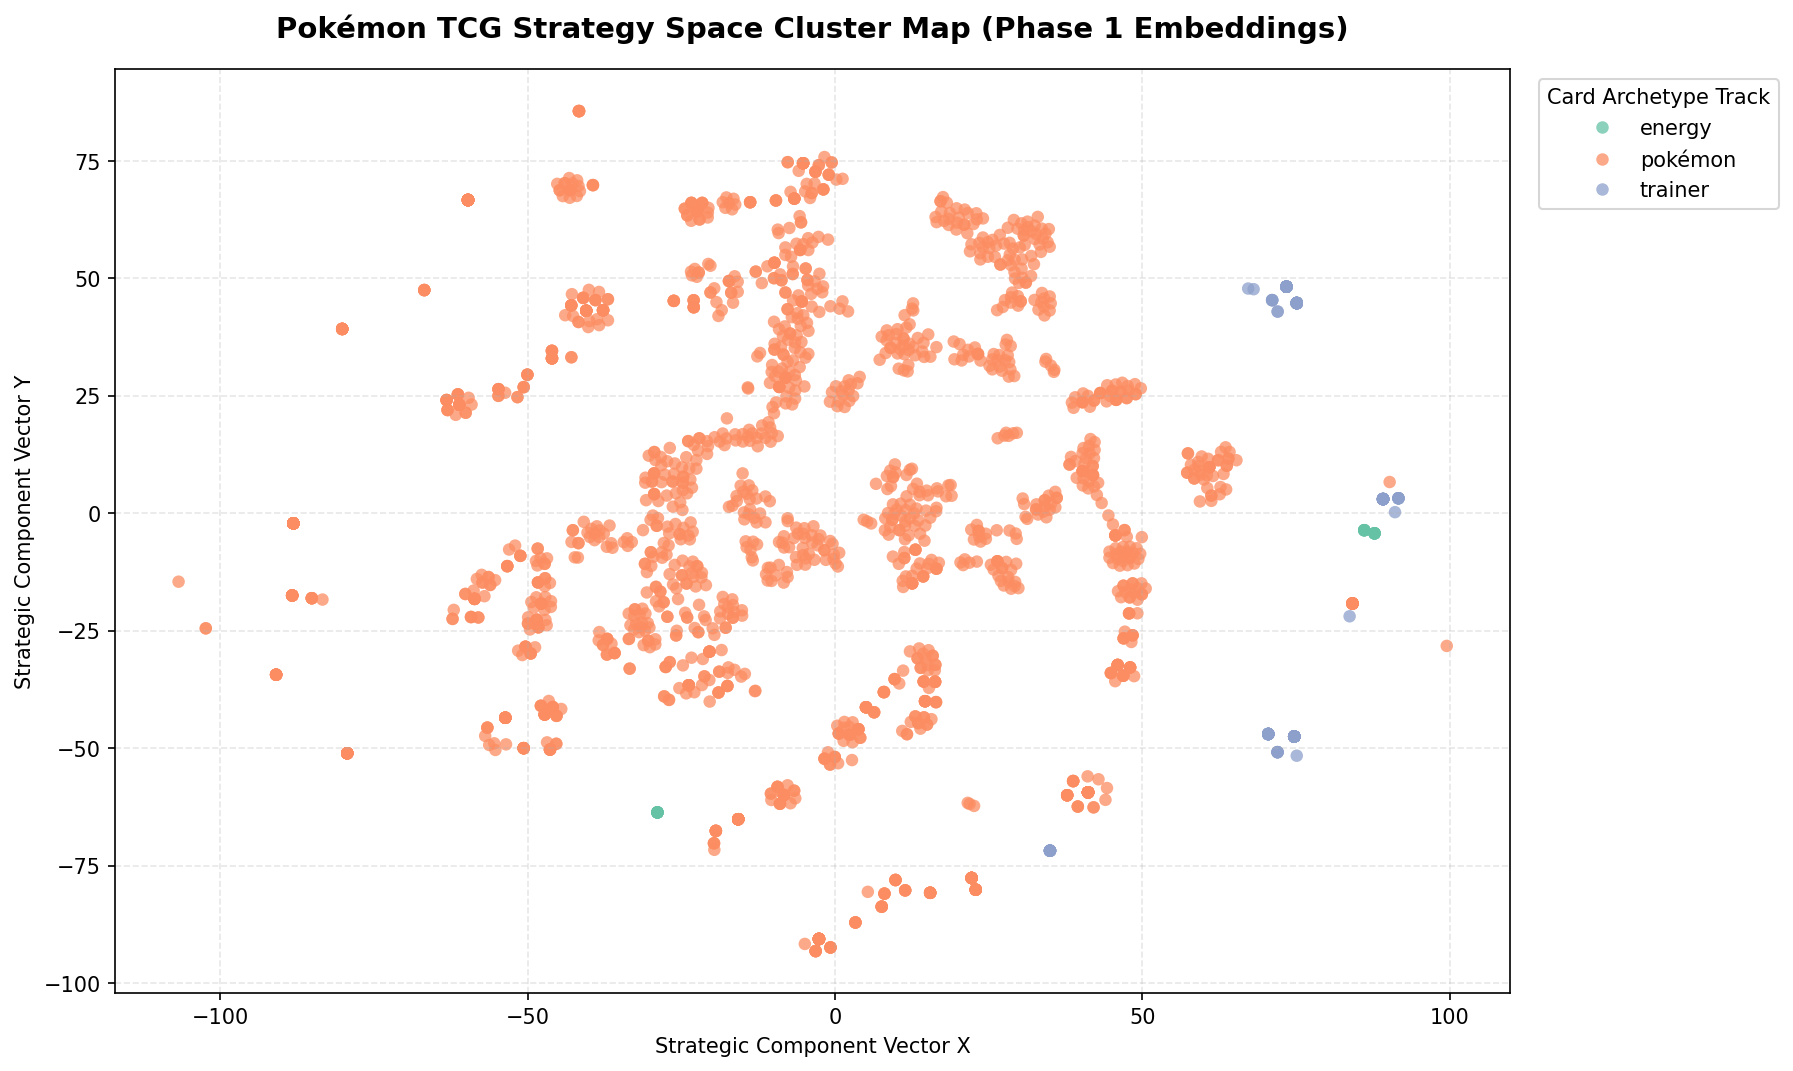

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings('ignore') # Silence layout adjustments warnings

print("🔮 Initializing t-SNE Dimensionality Reduction (128D -> 2D)...")

# 1. Fit and transform the dense embedding spaces
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
embeddings_2d = tsne.fit_transform(embeddings)

# 2. Build plotting structure dataframe
plot_df = pd.DataFrame({
    'x': embeddings_2d[:, 0],
    'y': embeddings_2d[:, 1],
    'Archetype / Class': categories
})

# 3. Render the matplotlib figure
plt.figure(figsize=(12, 8), dpi=150)
sns.scatterplot(
    x='x', y='y',
    hue='Archetype / Class',
    palette='Set2',
    data=plot_df,
    alpha=0.75,
    edgecolor='none'
)

plt.title("Pokémon TCG Strategy Space Cluster Map (Phase 1 Embeddings)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Strategic Component Vector X", fontsize=10)
plt.ylabel("Strategic Component Vector Y", fontsize=10)
plt.legend(title="Card Archetype Track", loc='upper right', bbox_to_anchor=(1.2, 1))
plt.grid(True, linestyle='--', alpha=0.3)

# Save the plot asset out to workspace to insert into your final Kaggle Report file
plt.savefig("pokemon_strategy_space_clusters.png", bbox_inches='tight')
print("💾 Plot successfully generated and exported to 'pokemon_strategy_space_clusters.png'!")
plt.show()